In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv("btcusd_1-min_data.csv")
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [23]:
# Convert timestamp to Date
df['Date'] = pd.to_datetime(df['Timestamp'], unit='s')

# Keep only Date and Close
df = df[['Date', 'Close']]

# Rename Close → Price
df.rename(columns={'Close': 'Price'}, inplace=True)
# Add lag features
df['lag_1'] = df['Price'].shift(1)
df['lag_2'] = df['Price'].shift(2)
df['lag_3'] = df['Price'].shift(3)

# Remove NaN rows
df.dropna(inplace=True)

df.head()

,Date,Price,lag_1,lag_2,lag_3
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58
5,2012-01-01 10:06:00,4.58,4.58,4.58,4.58
6,2012-01-01 10:07:00,4.58,4.58,4.58,4.58
7,2012-01-01 10:08:00,4.58,4.58,4.58,4.58


In [25]:
df = df.tail(2000)

In [26]:
predictionDays = 30
# Create another column shifted 'n'  units up
df['Prediction'] = df[['Price']].shift(-predictionDays)
# show the first 5 rows
df.head()

,Date,Price,lag_1,lag_2,lag_3,Prediction
7471282,2026-03-17 14:43:00,74258.0,74260.0,74238.0,74256.0,74131.0
7471283,2026-03-17 14:44:00,74260.0,74258.0,74260.0,74238.0,74151.0
7471284,2026-03-17 14:45:00,74367.0,74260.0,74258.0,74260.0,74200.0
7471285,2026-03-17 14:46:00,74373.0,74367.0,74260.0,74258.0,74233.0
7471286,2026-03-17 14:47:00,74376.0,74373.0,74367.0,74260.0,74243.0


In [28]:
X = np.array(df[['Price', 'lag_1', 'lag_2', 'lag_3']])
X = X[:-predictionDays]

y = np.array(df['Prediction'])
y = y[:-predictionDays]

In [29]:
df.tail()

,Date,Price,lag_1,lag_2,lag_3,Prediction
7473277,2026-03-18 23:58:00,71266.0,71270.0,71284.0,71284.0,NaN
7473278,2026-03-18 23:59:00,71259.0,71266.0,71270.0,71284.0,NaN
7473279,2026-03-19 00:00:00,71220.0,71259.0,71266.0,71270.0,NaN
7473280,2026-03-19 00:01:00,71219.0,71220.0,71259.0,71266.0,NaN
7473281,2026-03-19 00:02:00,71200.0,71219.0,71220.0,71259.0,NaN


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# set the predictionDays array equal to last 30 rows from the original data set
predictionDays_array = np.array(df[['Price']])[-predictionDays:]

In [32]:
from sklearn.svm import SVR
# Create and Train the Support Vector Machine (Regression) using radial basis function
svr_rbf = SVR(kernel='rbf', C=10000, gamma=0.001)
svr_rbf.fit(X_train_scaled, y_train)

SVR(C=10000, gamma=0.001)

In [33]:
svr_rbf = SVR(kernel='rbf', C=1e3, gamma=0.00001)
svr_rbf.fit(X_train_scaled, y_train)

SVR(C=1000.0, gamma=1e-05)

In [34]:
# print the predicted values
svm_prediction = svr_rbf.predict(X_test_scaled)
print(svm_prediction)
print()
print(y_test)

[74034.30811848 74052.79828379 73854.2559191  73957.99637983
 74018.37561257 74032.51408518 74011.33439616 73867.62664575
 73996.87783143 74024.78434505 73818.26556895 73872.76200277
 74014.35596934 74010.69527795 73823.91376818 73820.46433819
 74053.62547184 74030.28746234 73930.90084844 74053.01611213
 73845.30667383 74050.03276627 74068.62832972 73819.21431896
 74021.62783898 73822.21098985 73807.41815974 74031.90079674
 74060.10885557 73803.46986986 74060.94815981 73822.72270624
 74050.35006242 74058.41423319 74054.43250478 74008.75276544
 74051.37268578 73985.84667826 74027.46090517 74015.52083166
 73812.61997903 74017.49277817 73875.50413746 74046.42536025
 73819.60724224 73823.85497893 73809.93699999 73829.78793004
 74022.91723981 74009.96815214 73947.50903172 74032.3026095
 73900.57471327 73803.66605388 74007.70272564 73816.87009735
 74020.36188397 74024.69503827 74012.33272292 74048.3131618
 73893.92863503 73827.28145572 74035.7242121  73829.1405271
 73845.71500597 73807.41469

R2 Score: -0.22996398598032908
RMSE: 1525.1092907331831


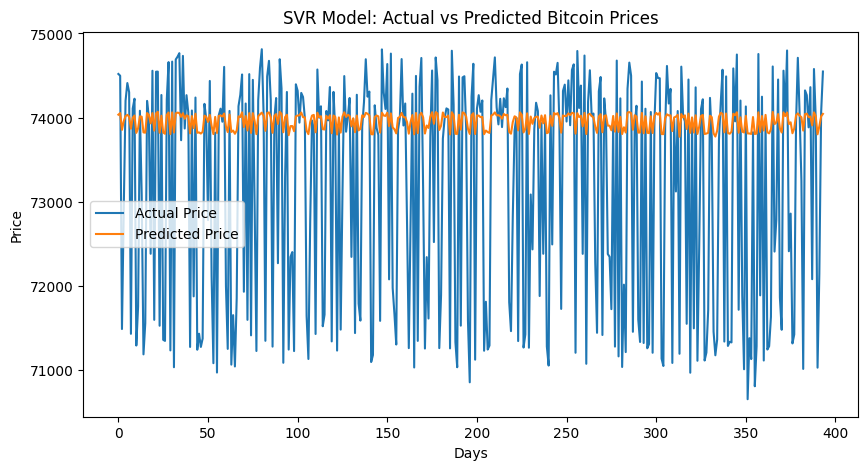

In [35]:
y_pred = svr_rbf.predict(X_test_scaled)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot actual vs predicted
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title("SVR Model: Actual vs Predicted Bitcoin Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

In [37]:
# Print the model predictions for the next 30 days
prediction_days_array = np.array(df[['Price', 'lag_1', 'lag_2', 'lag_3']])[-predictionDays:]
prediction_days_array_scaled = scaler.transform(prediction_days_array)
future_prediction = svr_rbf.predict(prediction_days_array_scaled)

print("Predicted Bitcoin Prices for Next 30 Days:")
print(future_prediction)

print("Actual Bitcoin Prices for Last 30 Days:")
print(df.tail(predictionDays))

Predicted Bitcoin Prices for Next 30 Days:
[73820.15289129 73821.73648136 73822.56205887 73823.28353794
 73823.68911677 73823.54734489 73823.88144909 73823.68732224
 73823.12404747 73822.38224271 73821.55545445 73820.81670961
 73819.72477103 73819.24874228 73820.4165971  73821.49240448
 73822.96943088 73824.37365521 73822.60964763 73820.84799479
 73819.5117979  73818.26522877 73818.75954718 73819.44577179
 73819.60318756 73819.67237235 73819.23200923 73818.103794
 73817.20566047 73816.04349994]
Actual Bitcoin Prices for Last 30 Days:
                       Date    Price    lag_1    lag_2    lag_3  Prediction
7473252 2026-03-18 23:33:00  71324.0  71296.0  71271.0  71240.0         NaN
7473253 2026-03-18 23:34:00  71330.0  71324.0  71296.0  71271.0         NaN
7473254 2026-03-18 23:35:00  71318.0  71330.0  71324.0  71296.0         NaN
7473255 2026-03-18 23:36:00  71337.0  71318.0  71330.0  71324.0         NaN
7473256 2026-03-18 23:37:00  71347.0  71337.0  71318.0  71330.0         NaN
7473